In [71]:
# Importación de librerías esenciales para el análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

print("Librerías cargadas exitosamente.")

Librerías cargadas exitosamente.


In [72]:
# Estilo de gráficos
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

## 📌 Extracción

In [73]:
# Cargar datos desde la URL
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
df = pd.read_json(url)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [74]:
# Información de columnas y tipos de datos
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


## 🔧 Transformación

In [75]:
# Expandimos el DataFrame normalizando las columnas
df_normalizado = pd.concat([
    df.drop(['customer', 'phone', 'internet', 'account'], axis=1), # Eliminamos las columnas anidadas
    pd.json_normalize(df['customer']),  # Normalizamos datos de cliente
    pd.json_normalize(df['phone']),     # Normalizamos datos de teléfono
    pd.json_normalize(df['internet']),  # Normalizamos datos de internet
    pd.json_normalize(df['account'])    # Normalizamos datos de cuenta
], axis=1)

# Mostramos las primeras filas del nuevo DataFrame
df_normalizado.sample()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
5713,7808-DVWEP,No,Male,0,Yes,No,3,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.0,49.65


In [76]:
# Mostrando el DataFrame aleatoriamente
df_normalizado.sample(10) 

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
4604,6311-UEUME,Yes,Female,0,No,No,29,Yes,No,Fiber optic,...,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,78.90,2384.15
3383,4695-WJZUE,Yes,Female,1,No,No,2,Yes,Yes,Fiber optic,...,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,88.55,179.25
6689,9208-OLGAQ,No,Female,1,No,No,18,Yes,No,Fiber optic,...,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,84.95,1443.65
2558,3569-VLDHH,No,Male,0,Yes,Yes,66,Yes,No,DSL,...,Yes,Yes,Yes,Yes,No,One year,Yes,Electronic check,75.10,5013
3414,4726-DLWQN,No,Male,1,No,No,50,Yes,Yes,DSL,...,Yes,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),70.35,3454.6
4905,6705-LNMDD,No,Male,0,No,No,20,Yes,No,DSL,...,No,No,Yes,No,No,Month-to-month,No,Mailed check,50.00,1003.05
190,0301-KOBTQ,No,Male,0,No,No,32,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.05,614.45
6025,8224-KDLKN,No,Male,0,Yes,Yes,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.00,1738.9
6270,8627-EHGIP,Yes,Male,0,No,No,44,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,One year,Yes,Mailed check,53.95,2375.4
6046,8256-TWSNM,,Male,0,Yes,Yes,6,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.80,377.85


In [77]:
# Información de columnas y tipos de datos
df_normalizado.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [78]:
# Verificación de datos nulos
df_normalizado.isna().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [79]:
# Cambiamos el nombre  de "Charges.Monthly" y "Charges.Total"
df_normalizado.rename(columns={
    'Charges.Monthly': 'ChargesMonthly',
    'Charges.Total': 'ChargesTotal'
}, inplace=True)

# Cambiamos el tipo de variable de "ChargesMonthly" y "ChargesTotal"
df_normalizado['ChargesMonthly'] = pd.to_numeric(df_normalizado['ChargesMonthly'], errors='coerce')
df_normalizado['ChargesTotal'] = pd.to_numeric(df_normalizado['ChargesTotal'], errors='coerce')

In [80]:
df_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [81]:
# Renombramos las columnas de customer ID, gender y tenure
df_normalizado.rename(columns={
    'customerID': 'Customer_ID',
    'gender': 'Gender',
    'tenure': 'Tenure'
}, inplace=True)

In [82]:
# Mostramos las últimas 5 filas
df_normalizado.tail() 

,Customer_ID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.60


In [83]:
# Creamos nueva Columna y dividiendo cada valor entre 30
df_normalizado['daily_accounts'] = df_normalizado['ChargesMonthly'] / 30

In [84]:
# Verificamos una muestra
df_normalizado.sample(5)

,Customer_ID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,daily_accounts
4031,5515-RUGKN,No,Male,0,No,No,8,Yes,No,DSL,...,No,No,No,Yes,Month-to-month,Yes,Credit card (automatic),54.75,438.05,1.825000
65,0107-YHINA,Yes,Male,0,No,Yes,1,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.75,99.75,3.325000
3394,4706-AXVKM,Yes,Female,1,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Credit card (automatic),84.80,906.85,2.826667
1256,1803-BGNBD,No,Female,0,No,No,12,Yes,No,DSL,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,54.30,654.50,1.810000
872,1228-ZLNBX,No,Male,0,No,No,21,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,No,Mailed check,75.30,1570.70,2.510000


In [85]:
# Columnas a transformar en binario - Solo columnas puras "Yes"/"No".
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Aplicamos la transformación a binario
df_normalizado[binary_cols] = df_normalizado[binary_cols].apply(lambda x: x.map({'Yes': 1, 'No': 0}))

df_normalizado.sample(5)

,Customer_ID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,daily_accounts
4250,5845-BZZIB,No,Male,0,1,1,35,1,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.10,655.30,0.670000
5780,7901-HXJVA,No,Male,0,0,0,14,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,0,Electronic check,76.45,1117.55,2.548333
7217,9927-DSWDF,No,Male,0,1,0,22,1,No,Fiber optic,...,No,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.60,2180.55,3.486667
4113,5642-MHDQT,No,Female,0,1,1,53,1,No,No,...,No internet service,No internet service,No internet service,No internet service,One year,1,Bank transfer (automatic),19.85,1039.45,0.661667
3905,5338-YHWYT,No,Male,0,0,1,37,1,No,DSL,...,No,Yes,No,No,Two year,0,Credit card (automatic),61.45,2302.35,2.048333


In [86]:
# Reemplazar el valor "No phone service" por "No" en MultipleLines.
df_normalizado['MultipleLines'] = df_normalizado['MultipleLines'].replace('No phone service', 'No')
df_normalizado['MultipleLines'].value_counts()

,count
MultipleLines,
No,4202
Yes,3065


In [87]:
# Convertir los valores "Yes"/"No" a 1/0 en MultipleLines.
df_normalizado['MultipleLines'] = df_normalizado['MultipleLines'].map({'Yes': 1, 'No': 0})
df_normalizado['MultipleLines'].head()

,MultipleLines
0,0
1,1
2,0
3,0
4,0


In [88]:
df_normalizado.Contract.value_counts()

,count
Contract,
Month-to-month,4005
Two year,1743
One year,1519


In [89]:
# Reemplazar valores en Contract según criterios definidos.
contract_mapping = {
    'Month-to-month': 1,
    'One year': 2,
    'Two year': 3
}

df_contract = pd.DataFrame(list(contract_mapping.items()), columns=['Contract Type', 'Code'])
print(df_contract)

    Contract Type  Code
0  Month-to-month     1
1        One year     2
2        Two year     3


In [90]:
# Columnas donde el valor es "Sí" será 1 y el resto 0.
binary_cols_2 = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols_2:
    df_normalizado[col] = df_normalizado[col].apply(lambda x: 1 if x == 'Yes' else 0)

df_normalizado

,Customer_ID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,daily_accounts
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.261667


In [91]:
# Recorremos la columna 'Churn'.
# Si el valor es 'Yes' o 'No', lo conservamos tal cual.
# Para cualquier otro valor, lo reemplazamos por 'N/A'.
df_normalizado['Churn'] = df_normalizado['Churn'].apply(lambda x: x if x == 'Yes' or x =='No' else 'N/A')
df_normalizado

,Customer_ID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,daily_accounts
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.261667


In [92]:
# Conteo de valores
df_normalizado['Churn'].value_counts() 

,count
Churn,
No,5174
Yes,1869
N/A,224


In [93]:
# 1. Reemplazamos el texto "N/A" por el valor nulo real de Numpy (np.nan)
df_normalizado['Churn'] = df_normalizado['Churn'].replace('N/A', np.nan)

In [94]:
# Eliminamos las filas donde 'Churn' es nulo y creamos un DataFrame final a partir del DataFrame normalizado
df_final = df_normalizado.dropna(subset=['Churn']).copy()
print(df_final['Churn'].value_counts(dropna=False))

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [95]:
# Exportamos el DataFrame final en formato .json
df_final.to_json('Churn_de_Clientes.json', index= False)

## 📊 **Carga y análisis**

In [96]:
# Análisis descriptivo de las métricas numéricas
df_final.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,7043,7043,9995-HOTOH,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,7043,2,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043.0,NaN,NaN,NaN,0.483033,0.499748,0.0,0.0,0.0,1.0,1.0
Dependents,7043.0,NaN,NaN,NaN,0.299588,0.45811,0.0,0.0,0.0,1.0,1.0
Tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043.0,NaN,NaN,NaN,0.903166,0.295752,0.0,1.0,1.0,1.0,1.0
MultipleLines,7043.0,NaN,NaN,NaN,0.421837,0.493888,0.0,0.0,0.0,1.0,1.0
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
# Comparamos el comportamiento promedio de los que se fueron vs los que no
print("Comparativa de medias por Churn:")
df_final.groupby('Churn').mean(numeric_only=True).round(2).T

Comparativa de medias por Churn:


Churn,No,Yes
SeniorCitizen,0.13,0.25
Partner,0.53,0.36
Dependents,0.34,0.17
Tenure,37.57,17.98
PhoneService,0.90,0.91
MultipleLines,0.41,0.45
OnlineSecurity,0.33,0.16
OnlineBackup,0.37,0.28
DeviceProtection,0.36,0.29
TechSupport,0.34,0.17


### Gráfico de Distribución de Churn según los clientes activos y dados de baja

In [98]:
# Conteo de clientes activos y dados de baja agrupados por 'Churn'
df_1 = df_final.groupby('Churn').size().reset_index(name='Total')
df_1 = df_1.set_index('Churn')

# Calculamos el porcentaje sobre el total
df_1['Porcentaje'] = (df_1['Total'] / df_1['Total'].sum() * 100).round(2)
print("Resumen de Evasión (Churn):")
df_1

Resumen de Evasión (Churn):


,Total,Porcentaje
Churn,,
No,5174,73.46
Yes,1869,26.54


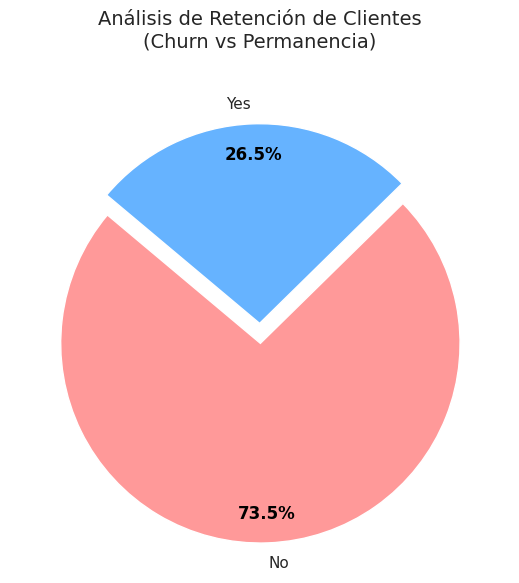

In [113]:
# Definimos los colores y el gráfico a utilizar
colores = ['#ff9999','#66b3ff']

explode_personalizado = [0.1] + [0] * (len(df_1) - 1)
plt.figure(figsize=(6, 6))

# Creamos el gráfico
wedges, texts, autotexts = plt.pie(
    df_1['Total'], 
    labels=df_1.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colores,
    pctdistance=0.85, # Mueve el % hacia afuera
    explode=explode_personalizado
)

# Definimos la estética de los textos
plt.setp(autotexts, size=12, weight="bold", color="black")
plt.title('Análisis de Retención de Clientes\n(Churn vs Permanencia)', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('grafico_churn.png', dpi=300, bbox_inches='tight')
plt.show()
     

In [114]:
# Filtrado de clientes que se dieron de baja (Churn = "Yes")
client_evade = df_final.query('Churn == "Yes"').copy().reset_index(drop=True)
client_evade.head()

,Customer_ID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,daily_accounts
0,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
1,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
2,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667
3,0022-TCJCI,Yes,Male,1,0,0,45,1,0,DSL,...,1,0,0,1,One year,0,Credit card (automatic),62.7,2791.50,2.090000
4,0023-HGHWL,Yes,Male,1,0,0,1,0,0,DSL,...,0,0,0,0,Month-to-month,1,Electronic check,25.1,25.10,0.836667


### Mapa de Calor del Churn según Género, Contrato e InternetService

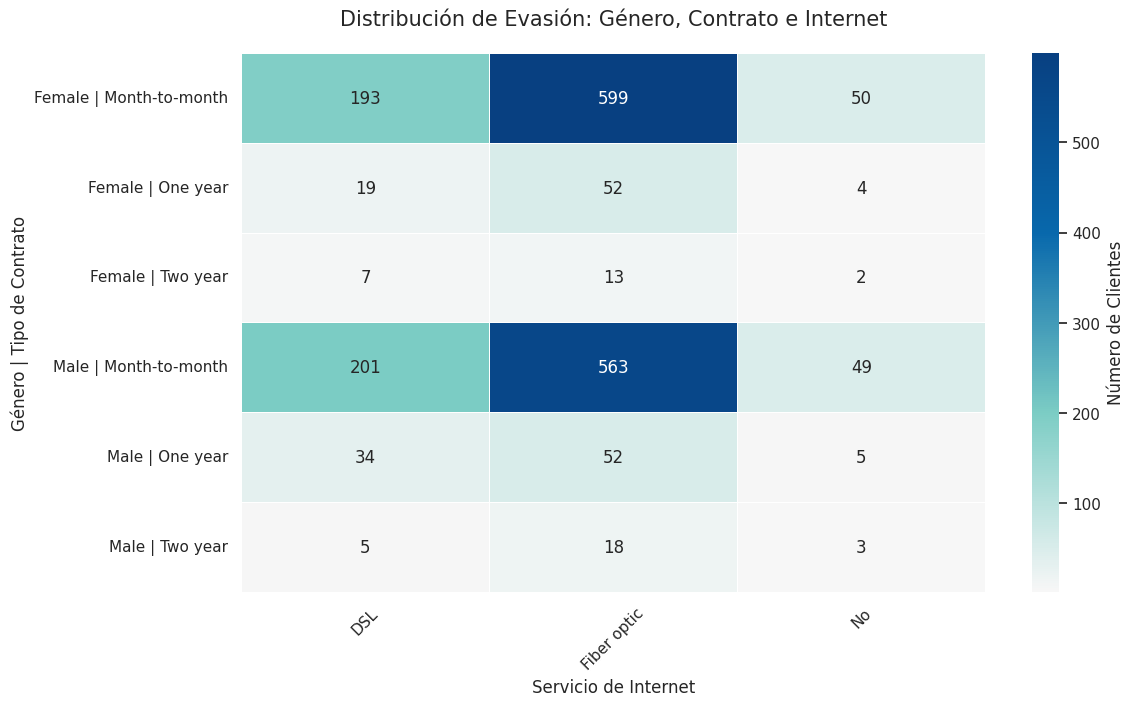

In [115]:
from matplotlib.colors import LinearSegmentedColormap
cliente_evade = client_evade.copy()
cliente_evade['Gender_Contract'] = cliente_evade['Gender'] + " | " + cliente_evade['Contract']
heatmap_data = cliente_evade.groupby(['Gender_Contract', 'InternetService']).size().unstack()

colores = ["#f7f7f7", "#7bccc4", "#0868ac", "#084081"] 
semaforo_pro = LinearSegmentedColormap.from_list("custom_cool", colores)

plt.figure(figsize=(12, 7))

sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='d', 
            cmap=semaforo_pro, 
            linewidths=.5, 
            cbar_kws={'label': 'Número de Clientes'})

plt.title('Distribución de Evasión: Género, Contrato e Internet', fontsize=15, pad=20)
plt.xlabel('Servicio de Internet', fontsize=12)
plt.ylabel('Género | Tipo de Contrato', fontsize=12)

plt.xticks(rotation=45)
plt.show()

### Boxplot Comparativo para variables numéricas por estado de Churn

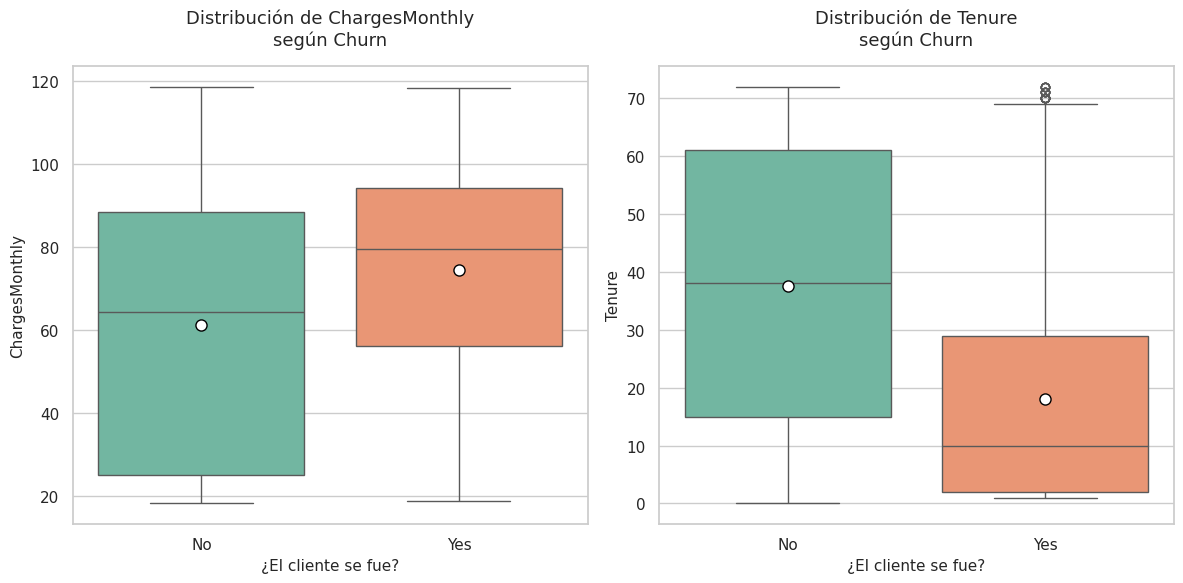

In [ ]:
def graficar_boxplots_categoricos(df, variables_num, target_cat):
    # Configuramos el estilo
    sns.set_theme(style="whitegrid")
    
    # Creamos la figura
    fig, axs = plt.subplots(1, len(variables_num), figsize=(12, 6))
    
    # Usamos la paleta que definimos antes para mantener coherencia visual
    for i, var in enumerate(variables_num):
        sns.boxplot(
            ax=axs[i],
            x=target_cat, 
            y=var, 
            data=df, 
            palette='Set2', 
            hue=target_cat, 
            legend=False,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
        )
        
        # Personalización de títulos y etiquetas
        axs[i].set_title(f'Distribución de {var}\nsegún {target_cat}', fontsize=13, pad=15)
        axs[i].set_xlabel('¿El cliente se fue?', fontsize=11)
        axs[i].set_ylabel(var, fontsize=11)
        
    plt.tight_layout()
    return fig

# Ejecutamos
variables_a_analizar = ['ChargesMonthly', 'Tenure']
grafica_final = graficar_boxplots_categoricos(df_final, variables_a_analizar, 'Churn')
plt.show()

## 📄Informe Final

### 1. Introducción

El objetivo de este análisis de datos fue de identificar los principales factores que inciden en la fuga de clientes (**Churn**) en la compañía **TelecomX**. El hecho de entender por qué los clientes cancelan su suscripción a los servicios que brindan la compañía es crucial para desarrollar estrategias de retención del cliente efectivas y así asegurar la estabilidad y rentabilidad de la compañía.

### 2. Tratamiento de Datos

Para preparar los datos para el análisis, se ejecutaron los siguientes pasos clave:
* **Extracción y Transformación**: Se cargaron los datos desde un archivo .json y se normalizó su estructura anidada para crear un formato tabular.
* **Limpieza y Estandarización**: Se verificó la ausencia de datos nulos o duplicados. Las columnas categóricas (ej. `Partner`, `Dependents`, servicios de internet) se convirtieron a un formato numérico binario (**1** para \"Sí\", **0** para \"No\") para facilitar el análisis.
* **Ajuste del Tipo de Dato**: Se corrigieron los tipos de datos, especialmente en las columnas de cargos (`Charges.Monthly`, `Charges.Total`), para permitir cálculos numéricos.

### 3. Análisis Exploratorio y Hallazgos Clave

El análisis visual de los datos reveló patrones claros sobre los clientes que abandonan el servicio:
* **Tasa de Churn General**: La compañía tiene una tasa de churn del **26.5%**, una cifra considerable que impacta directamente en los ingresos.
* **Perfil de Mayor Riesgo**: El mapa de calor muestra que la combinación de **Contrato Mes a Mes** y servicio de **Fibra Óptica** concentra la mayor cantidad de cancelaciones. Este segmento es el más vulnerable.
* **Impacto de la Antigüedad y el Costo**: Los diagramas de caja revelaron que los clientes que cancelan el servicio prestado tienen una antigüedad mucho menor (mediana de **10 meses** vs. **40 meses** de clientes leales), así como también pagan una suscripción mensual más alta.

### 4. Conclusiones y Recomendaciones Estratégicas

**Conclusión Principal**: El churn en la compañia TelecomX está fuertemente impulsado por clientes nuevos con planes flexibles (**mes a mes**) y servicios premium (**fibra óptica**), que probablemente no perciben un valor suficiente para justificar el costo a largo plazo.

**Recomendaciones**:
* Acciones de Retención Focalizadas: Crear ofertas de descuento para que los clientes del segmento de **Fibra Óptica + Contrato Mensual** migren a planes de 1 o 2 años.
* Evaluar la Oferta de Fibra Óptica: Analizar la estructura de precios y la calidad del servicio de fibra para asegurar que sea competitiva y cumpla con las expectativas de los clientes que pagan más.